# Shape-conditioned curvature allocation: measured organoid mean and spread

Train explicit fate-energy models and a plain depth-1 GIN to predict **where curvature occurs, given each organoid's measured mean and standard deviation**. This is a conditional reconstruction task: held-out organoid summaries are intentionally supplied, and its errors must not be presented as independent fate-only prediction accuracy.

For cell i in organoid g, the main target is z=(H-mean_g)/max(SD_g, floor). Mean curvature H is restored from the saved reference's physical residuals after its original training-fitted target cleanup. All cells receive equal weight. The SD floor is fixed from the inner-training organoids only. The control target subtracts the measured mean without rescaling. No measured cell-level curvature, summaries, local geometry or global features enter the fate model; summaries are used only to define targets and reconstruct predictions.

The explicit model uses constant center preferences, all-to-all **one-hop presence** interactions and a fixed accommodation grid. During fitting and inference its output is projected to zero organoid mean. This introduces a reference convention: coefficients describe relative allocations, not absolute native curvature. It does not force predicted variance to match measured variance. A standardized center-only model and a standardized plain GIN are controls. Exact outer and inner splits, baseline references, observed moments, model specifications and preprocessing are saved for independent analysis.

All settings are near the top. Scientific loops remain visible in the notebook. This notebook trains; the companion `experiments/benchmarks/shape_conditioned_energy_evaluation.ipynb` restores checkpoints and performs detailed comparisons.

In [1]:
from pathlib import Path
import sys
import copy
import json
import shutil
import hashlib
from dataclasses import asdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display
from torch_geometric.loader import DataLoader
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p/'src/models/gnn.py').is_file())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.artifacts.bundle import load_bundle, save_bundle
from src.artifacts.paths import training_run_path
from src.data.target_transforms import ObservedGraphMoments, center_graph_values
from src.data.neighborhood_counts import fate_identities
from src.models.gnn import GINCurvature
from src.models.size_models import seed_all
from src.training.coupled_fit import graph_samples
from src.training.energy_fit import fit_energy_fixed
from src.training.progress import TrainingProgress


## Settings
Choose the saved cohort and verify its exposed data settings. Model, normalization and optimizer settings are independent of the old model. A new output folder is created by default. Set RESUME_RUN only to resume the exact same configuration; completed model bundles are restored rather than overwritten.

In [2]:
# Execution and matched data reference
RUN_TRAINING = True  # Fit a new conditional reconstruction experiment.
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'  # CUDA is used for energy solves and GIN training.
SHOW_PROGRESS = True  # Show the current model, fold, gamma and epoch.
REFERENCE_RUN = 'training_results/energy_model_training/all_to_all_presence_hop1_matched_20261002_130854'  # Exact saved splits, cleaned physical targets and prior models.
RESUME_RUN = 'training_results/shape_conditioned_energy_training/observed_mean_std_presence_20261002_144511'  # Existing incomplete output folder, or None for a new timestamped folder.

SETTINGS = dict(
    # Run identity and cohort checks against the saved reference
    tag='observed_mean_std_presence',  # Purpose label in training_results/shape_conditioned_energy_training/.
    dataset='after_cleanup',  # Required reference dataset.
    target_indices=[1],  # Mean curvature only.
    timepoints=['day4', 'day4p5', 'day4p5-more'],  # Shared selection for training and validation.
    sphericity_max=.93,  # Larger values are the separate external spherical cohort.
    exclusive_markers=True,  # All-zero fate is the Unassigned identity.
    n_folds=5,  # Exact folds are inherited and verified, never resampled.
    split_seed=42,  # Verify the original split seed.
    interpolate_outliers=True,  # Reuse original fold-specific target cleanup, without refitting.

    # Conditional target definition
    target_modes=['standardized', 'mean_only'],  # (H-mean)/std versus mean subtraction alone.
    std_floor_fraction=.1,  # Floor is this fraction of median organoid SD in inner-training data.
    std_floor_absolute=1e-6,  # Positive physical-unit lower bound on the SD floor.
    zero_mean_output=True,  # Project predictions to zero graph mean during training AND inference.
    variance_ddof=0,  # Population variance over equally weighted cells; no cell-area weighting.

    # Local fate model
    source_markers=['Agr2', 'AldoB', 'Chroma', 'KI67', 'LGR5', 'Lysozyme', 'Serotonin', 'Unassigned'],  # One-hop interaction sources.
    recipient_markers=['Agr2', 'AldoB', 'Chroma', 'KI67', 'LGR5', 'Lysozyme', 'Serotonin', 'Unassigned'],  # All recipient identities.
    activation='presence',  # Literal 1[at least one source neighbor]; fixed, not learned.
    interaction_radius=1,  # Direct interaction radius; accommodation uses the full graph.
    min_pair_organoids=20,  # Support flag for interpretation; no automatic removal.
    center_only_enabled=True,  # Fit an uncoupled center-identity model in standardized units.

    # Accommodation grid and training-only selection
    gamma_grid=[0., .1, .2, .4, .8, 1.6, 3.2, 6.4, 12.8, 25.6],  # Fixed accommodation strengths.
    center_ridge=.0001,  # Preference penalty relative to training target RMS.
    pair_ridge_grid=[.0001, .001],  # Select the pair penalty on the same inner holdout at each gamma.
    inner_fraction=.2,  # Ordinary-training holdout for penalty/epoch/gamma selection.
    inner_seed=42,  # Same inner split in each variant and the original reference.
    solver_rtol=1e-11,  # CUDA energy solver relative tolerance.
    blas_threads=4,  # Torch and CPU linear-algebra thread limit.

    # Plain GIN comparator: standardized targets, no FiLM/global inputs
    gin_enabled=True,  # Train one GIN per fold, using the same observed-moment reconstruction.
    gin_depth=1,  # One message-passing layer, matching the direct interaction radius.
    gin_hidden_dim=128,  # Hidden and head width.
    gin_dropout=.1,  # Hidden dropout during training.
    gin_norm='batch',  # Hidden normalization; evaluation uses running statistics.
    gin_residual=True,  # Residual GIN connections.
    gin_seed=42,  # Add fold index for model initialization.
    gin_lr=.0003,  # AdamW learning rate.
    gin_weight_decay=.0001,  # AdamW penalty.
    gin_batch_size=128,  # Organoids per batch; loss weights organoids equally.
    gin_max_epochs=500,  # Maximum inner-selection epochs before a full-training refit.
    gin_patience=50,  # Early-stopping patience on inner standardized MSE.
    gin_min_delta=1e-6,  # Minimum improvement to reset patience.
    gin_grad_clip=2.,  # Gradient norm cap.
    gin_num_workers=0,  # Data-loader workers.
)
RUN_DIR = Path(RESUME_RUN) if RESUME_RUN else training_run_path(PROJECT_ROOT, 'shape_conditioned_energy_training', SETTINGS['tag'])  # New output, or resume identical settings.


## Restore physical targets, memberships and observed summaries
The reference supplies exact organoid membership and training-fitted target cleanup. Its baseline is added back to recover physical mean curvature and saved as a comparison; it is **not subtracted** in this experiment. The small SD floor is derived solely from the recorded inner-training subset. Each validation organoid supplies its own observed mean and SD by design. The displayed table documents cohort size and how often the floor is used.

In [3]:
reference=Path(REFERENCE_RUN)
if not reference.is_absolute():reference=PROJECT_ROOT/reference
if not (reference/'complete.json').exists():raise ValueError('Reference run is incomplete.')
reference_settings=json.loads((reference/'settings.json').read_text())
for name in ['dataset','target_indices','timepoints','sphericity_max','exclusive_markers','n_folds','split_seed','interpolate_outliers']:
    if SETTINGS[name]!=reference_settings[name]:raise ValueError(f'Reference mismatch: {name}')
if SETTINGS['variance_ddof']!=0 or not SETTINGS['zero_mean_output'] or SETTINGS['activation']!='presence' or SETTINGS['interaction_radius']!=1:
    raise ValueError('This experiment requires population variance, zero-mean prediction and one-hop presence.')
if set(SETTINGS['target_modes'])!={'standardized','mean_only'}:raise ValueError('Keep both normalization variants for this matched experiment.')
membership=json.loads((reference/'splits.json').read_text())
reference_records=json.loads((reference/'models.json').read_text())
marker_names=load_bundle(reference/'inputs/fold_0_mean')['marker_names']
identity_names=marker_names+['Unassigned']
source_indices=[identity_names.index(x) for x in SETTINGS['source_markers']]
recipient_indices=[identity_names.index(x) for x in SETTINGS['recipient_markers']]
torch.set_num_threads(SETTINGS['blas_threads'])
config=dict(SETTINGS,reference_run=str(reference),reference_settings=reference_settings,device=DEVICE,
    task='Conditional reconstruction given measured per-organoid mean and SD; not fate-only prediction',
    target_cleanup='Inherited training-fitted cleanup; observed moments computed afterward',
    baseline_subtraction=False,global_features=[],coefficient_units='standardized units or physical centered units, as recorded per model')
if not RUN_TRAINING:raise RuntimeError('Settings inspected. Enable RUN_TRAINING to fit.')
if RUN_DIR.exists():
    if json.loads((RUN_DIR/'settings.json').read_text())!=config:raise ValueError('Resume settings differ; choose a new run.')
else:
    RUN_DIR.mkdir(parents=True)
    (RUN_DIR/'settings.json').write_text(json.dumps(config,indent=2))
    for name in ['splits.json','cohort.csv','regions.csv.gz','exclusivity_rules.json']:
        shutil.copy2(reference/name,RUN_DIR/name)
(RUN_DIR/'history').mkdir(exist_ok=True)
(RUN_DIR/'predictions').mkdir(exist_ok=True)
records=json.loads((RUN_DIR/'models.json').read_text()) if (RUN_DIR/'models.json').exists() else []
cohort_table=pd.read_csv(reference/'cohort.csv')
display(cohort_table.groupby(['timepoint','cohort']).size().unstack('cohort',fill_value=0))
print('Output:',RUN_DIR,'| device:',DEVICE,'| exact outer folds:',len(membership))

# Moment floors use only the inner-training subset; all variants keep that floor on the full refit.
moment_rows=[];floor_rows=[]
for split in membership:
    fold=split['fold'];input_path=RUN_DIR/f'inputs/fold_{fold}_mean'
    if input_path.exists():
        prepared=load_bundle(input_path)
    else:
        old=load_bundle(reference/f'inputs/fold_{fold}_mean')
        ref_record=next(r for r in reference_records if r['fold']==fold and r['family']=='energy')
        inner=load_bundle(reference/ref_record['bundle'])['metrics']
        physical_groups={}
        for role,group in old['groups'].items():
            physical_groups[role]=[]
            for graph in group:
                g=graph.clone();oid=str(g.organoid_str)
                physical=np.asarray(old['transform'].inverse(g.y.cpu().numpy()),dtype=float).reshape(-1)+np.asarray(old['baseline_offsets'][oid]).reshape(-1)
                g.y=torch.as_tensor(physical,dtype=torch.float64)
                if 'global_feat' in g:del g['global_feat']
                fate_identities(g.x)
                physical_groups[role].append(g)
        if [str(g.organoid_str) for g in physical_groups['train']]!=split['train']:raise ValueError('Training membership changed.')
        if [str(g.organoid_str) for g in physical_groups['val']]!=split['validation']:raise ValueError('Validation membership changed.')
        if [str(g.organoid_str) for g in physical_groups['spherical']]!=split['spherical_validation']:raise ValueError('Spherical membership changed.')
        lookup={str(g.organoid_str):g for g in physical_groups['train']}
        order=np.random.default_rng(SETTINGS['inner_seed']).permutation(len(lookup))
        nv=max(1,min(len(lookup)-2,round(SETTINGS['inner_fraction']*len(lookup))))
        expected_train=[split['train'][i] for i in order[nv:]];expected_val=[split['train'][i] for i in order[:nv]]
        if expected_train!=inner['inner_train'] or expected_val!=inner['inner_validation']:raise ValueError('Inner split differs from reference.')
        training_std=[float(lookup[oid].y.std(correction=0)) for oid in inner['inner_train']]
        floor=max(SETTINGS['std_floor_absolute'],SETTINGS['std_floor_fraction']*float(np.median(training_std)))
        moments={str(g.organoid_str):ObservedGraphMoments.from_targets(g.y.numpy(),std_floor=floor) for group in physical_groups.values() for g in group}
        prepared=dict(physical_groups=physical_groups,moments=moments,std_floor=floor,marker_names=marker_names,
            reference_baseline=old['baseline'],reference_baseline_predictions=old['baseline_predictions'],
            reference_preprocessing={k:v for k,v in old.items() if k not in ['groups','baseline','baseline_predictions']},
            inner_train=inner['inner_train'],inner_validation=inner['inner_validation'],conditional_reconstruction=True)
        save_bundle(input_path,prepared,splits=split,provenance=dict(reference_run=str(reference),observed_heldout_moments=True))
    floor_rows.append(dict(fold=fold,std_floor=prepared['std_floor']))
    for role,group in prepared['physical_groups'].items():
        for g in group:
            m=prepared['moments'][str(g.organoid_str)]
            moment_rows.append(dict(fold=fold,cohort=role,organoid_str=str(g.organoid_str),**asdict(m),floor_applied=m.std<m.scale))
pd.DataFrame(moment_rows).to_csv(RUN_DIR/'observed_moments.csv',index=False)
pd.DataFrame(floor_rows).to_csv(RUN_DIR/'normalization_floors.csv',index=False)
display(pd.DataFrame(moment_rows).groupby(['fold','cohort']).agg(organoids=('organoid_str','size'),median_sd=('std','median'),floored=('floor_applied','sum')))


cohort,ordinary,spherical
timepoint,,
day4,233,97
day4p5,288,100
day4p5-more,348,127


Output: training_results/shape_conditioned_energy_training/observed_mean_std_presence_20261002_144511 | device: cuda | exact outer folds: 5


organoids  median_sd  floored
fold cohort                                  
0    spherical        324   0.028792        0
     train            695   0.066558        0
     val              174   0.067518        0
1    spherical        324   0.028792        0
     train            695   0.066558        0
     val              174   0.068213        0
2    spherical        324   0.028792        0
     train            695   0.066562        0
     val              174   0.067714        0
3    spherical        324   0.028792        0
     train            695   0.067226        0
     val              174   0.065523        0
4    spherical        324   0.028792        0
     train            696   0.067213        0
     val              173   0.065044        0

## Fit center preferences and presence interactions
For each target definition and accommodation value, select shrinkage on the identical inner organoid split, then refit all ordinary training organoids. The center-only control is uncoupled. Pair models include gamma=0 as the no-accommodation control. Zero-mean output is imposed in the design matrix before fitting, and preserved by symmetric graph accommodation. Prediction archives include physical and normalized fields; measured means and SDs never enter message passing.

In [4]:
def target_groups(prepared,mode):
    """Use saved observed moments, keeping them outside all model input vectors."""
    groups={}
    for role,graphs in prepared['physical_groups'].items():
        groups[role]=[]
        for graph in graphs:
            g=graph.clone();m=prepared['moments'][str(g.organoid_str)]
            scale=m.scale if mode=='standardized' else 1.
            g.y=(g.y-m.mean)/scale
            groups[role].append(g)
    return groups

def save_predictions(record,role,graphs,predictions,prepared):
    ids=[];offsets=[0];actual=[];predicted=[];standardized=[];truth_z=[];rows=[]
    for graph,pred in zip(graphs,predictions):
        oid=str(graph.organoid_str);m=prepared['moments'][oid];p=np.asarray(pred).reshape(-1)
        scale=m.scale if record['target_mode']=='standardized' else 1.
        physical=m.mean+scale*p;truth=graph.y.numpy().reshape(-1)
        if not np.isfinite(p).all() or abs(p.mean())>1e-6:raise ValueError('Expected finite zero-mean model output.')
        zhat=(physical-m.mean)/m.scale;z=(truth-m.mean)/m.scale
        ids.append(oid);offsets.append(offsets[-1]+len(p));actual.append(truth);predicted.append(physical);standardized.append(zhat);truth_z.append(z)
        rows.append(dict(key=record['key'],variant=record['variant'],target_mode=record['target_mode'],gamma=record['gamma'],fold=record['fold'],cohort=role,
            organoid_str=oid,mse=float(np.mean((physical-truth)**2)),standardized_mse=float(np.mean((zhat-z)**2)),mean_baseline_mse=float(np.mean((truth-m.mean)**2))))
    np.savez_compressed(RUN_DIR/'predictions'/f'{record["key"]}_{role}.npz',organoid_ids=np.array(ids),offsets=np.array(offsets),truth=np.concatenate(actual),prediction=np.concatenate(predicted),truth_z=np.concatenate(truth_z),prediction_z=np.concatenate(standardized))
    return rows

tasks=[]
for mode in SETTINGS['target_modes']:
    if mode=='standardized' and SETTINGS['center_only_enabled']:tasks.append((mode,'center_only',0.))
    tasks.extend((mode,'presence_energy',float(gamma)) for gamma in SETTINGS['gamma_grid'])
score_rows=[]
with TrainingProgress(len(membership)*len(tasks),show=SHOW_PROGRESS,log_path=RUN_DIR/'energy_progress.csv') as progress:
    for split in membership:
        fold=split['fold'];prepared=load_bundle(RUN_DIR/f'inputs/fold_{fold}_mean')
        for mode in SETTINGS['target_modes']:
            groups=target_groups(prepared,mode);samples=graph_samples(groups['train'],2)
            held={role:graph_samples(group,2) for role,group in groups.items() if role!='train' and group}
            for task_mode,variant,gamma in [t for t in tasks if t[0]==mode]:
                key=f'{mode}_{variant}_g{SETTINGS["gamma_grid"].index(gamma):02d}_f{fold}'
                record=dict(key=key,name=f'{mode}_{variant}',variant=variant,target_mode=mode,gamma=gamma,fold=fold,depth=0 if variant=='center_only' else 1,
                    family='energy',bundle=f'models/{key}',input_bundle=f'inputs/fold_{fold}_mean',output_projection='graph_mean',target_indices=[1])
                with progress.task(model=f'{mode}: {variant}, gamma={gamma:g}',depth=record['depth'],fold=fold):
                    if (RUN_DIR/record['bundle']).exists():
                        saved=load_bundle(RUN_DIR/record['bundle']);model=saved['model'];metrics=saved['metrics']
                    else:
                        model_settings=dict(n_markers=len(marker_names),pairs=variant!='center_only',activation=SETTINGS['activation'],interaction='pooled',center_response=False,
                            exposure_kind='fractions',pair_constraints='direct',source_indices=source_indices,recipient_indices=recipient_indices,interaction_radius=1,
                            min_pair_organoids=SETTINGS['min_pair_organoids'],zero_mean_output=True)
                        penalties=[dict(ridge=SETTINGS['center_ridge'],pair_ridge=p,slope_ridge=0.,lambda_ridge=0.,alpha_ridge=0.) for p in (SETTINGS['pair_ridge_grid'] if variant!='center_only' else [SETTINGS['pair_ridge_grid'][0]])]
                        model,metrics,trials=fit_energy_fixed(samples,model_settings=model_settings,strength=gamma,penalties=penalties,
                            seed=SETTINGS['inner_seed'],inner_fraction=SETTINGS['inner_fraction'],device=DEVICE,solver_rtol=SETTINGS['solver_rtol'],blas_threads=SETTINGS['blas_threads'])
                        if metrics['inner_train']!=prepared['inner_train'] or metrics['inner_validation']!=prepared['inner_validation']:raise ValueError('Energy inner membership differs.')
                        save_bundle(RUN_DIR/record['bundle'],dict(model=model,metrics=metrics,record=record),splits=split,provenance=dict(task='observed-moment conditional reconstruction'))
                        trials.to_json(RUN_DIR/'history'/f'{key}.json',orient='records',indent=2)
                    record['inner_mse']=metrics['best']['inner_mse']
                    records=[r for r in records if r['key']!=key]+[record]
                    (RUN_DIR/'models.json').write_text(json.dumps(records,indent=2))
                    for role,ss in held.items():
                        pred=model.predict_samples(ss,device=DEVICE,rtol=SETTINGS['solver_rtol'])
                        score_rows+=save_predictions(record,role,prepared['physical_groups'][role],pred,prepared)
            pd.DataFrame(score_rows).to_csv(RUN_DIR/'energy_validation_mse.csv',index=False)
print('Energy fits complete:',sum(r['family']=='energy' for r in records))


/home/fmoller/Projects/LearningOrganoids/GraphNN/src/models/energy_ops.py:121: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  self.laplacian = torch.sparse_csr_tensor(self.crow,self.col,self.lap_values,size=lap.shape,device=self.device)


Energy fits complete: 105


## Train the plain GIN comparison
Train a depth-1 GIN without FiLM or global features on standardized targets. Subtract each graph's predicted mean inside the differentiable loss and at inference, matching the energy model's reconstruction constraint. Use inner validation to select the number of epochs, then reinitialize and refit the complete ordinary-training partition. Outer and spherical validation cannot select epochs.

In [5]:
def gin_loss(model,batch):
    (mu,_),_=model(batch.x,batch.edge_index,data=batch)
    prediction=center_graph_values(mu.reshape(-1),batch.batch)
    squared=(prediction-batch.y.reshape(-1)).square()
    total=torch.zeros(batch.num_graphs,device=squared.device,dtype=squared.dtype)
    total.index_add_(0,batch.batch,squared)
    return (total/(batch.ptr[1:]-batch.ptr[:-1])).mean()

def gin_epoch(model,loader,optimizer=None):
    model.train(optimizer is not None);total=0.;count=0
    for batch in loader:
        if 'global_feat' in batch:raise ValueError('No global or observed-moment inputs are permitted.')
        batch=batch.to(DEVICE)
        with torch.set_grad_enabled(optimizer is not None):
            loss=gin_loss(model,batch)
            if optimizer is not None:
                optimizer.zero_grad();loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(),SETTINGS['gin_grad_clip']);optimizer.step()
        total+=float(loss.detach())*batch.num_graphs;count+=batch.num_graphs
    return total/count

def new_gin(fold):
    seed_all(SETTINGS['gin_seed']+fold)
    return GINCurvature(n_markers=len(marker_names),hidden_dim=SETTINGS['gin_hidden_dim'],num_layers=SETTINGS['gin_depth'],
        dropout=SETTINGS['gin_dropout'],norm=SETTINGS['gin_norm'],residual=SETTINGS['gin_residual'],global_dim=0).to(DEVICE)

def gin_loader(graphs,shuffle):
    return DataLoader(graphs,batch_size=SETTINGS['gin_batch_size'],shuffle=shuffle,num_workers=SETTINGS['gin_num_workers'])

def gin_predict(model,graphs):
    result=[];model.to(DEVICE).eval()
    with torch.no_grad():
        for batch in gin_loader(graphs,False):
            batch=batch.to(DEVICE);(mu,_),_=model(batch.x,batch.edge_index,data=batch)
            pred=center_graph_values(mu.reshape(-1),batch.batch).cpu().numpy()
            result.extend([pred[int(a):int(b)] for a,b in zip(batch.ptr[:-1],batch.ptr[1:])])
    return result

gin_rows=[]
if SETTINGS['gin_enabled']:
    with TrainingProgress(len(membership),show=SHOW_PROGRESS,log_path=RUN_DIR/'gin_progress.csv') as progress:
        for split in membership:
            fold=split['fold'];prepared=load_bundle(RUN_DIR/f'inputs/fold_{fold}_mean')
            groups=target_groups(prepared,'standardized')
            for group in groups.values():
                for g in group:g.y=g.y.float()
            lookup={str(g.organoid_str):g for g in groups['train']}
            key=f'standardized_gin_d{SETTINGS["gin_depth"]}_f{fold}'
            record=dict(key=key,name='standardized_gin',variant='gin',target_mode='standardized',gamma=None,fold=fold,depth=SETTINGS['gin_depth'],family='gin',
                bundle=f'models/{key}',input_bundle=f'inputs/fold_{fold}_mean',output_projection='graph_mean',target_indices=[1])
            with progress.task(model='Standardized plain GIN: inner epoch selection and full refit',depth=SETTINGS['gin_depth'],fold=fold):
                if (RUN_DIR/record['bundle']).exists():
                    saved=load_bundle(RUN_DIR/record['bundle']);model=saved['model'];metrics=saved['metrics']
                else:
                    inner_train=[lookup[oid] for oid in prepared['inner_train']];inner_val=[lookup[oid] for oid in prepared['inner_validation']]
                    model=new_gin(fold);optimizer=torch.optim.AdamW(model.parameters(),lr=SETTINGS['gin_lr'],weight_decay=SETTINGS['gin_weight_decay'])
                    train_loader=gin_loader(inner_train,True);val_loader=gin_loader(inner_val,False)
                    best=float('inf');best_epoch=0;stale=0;history=[]
                    for epoch in range(1,SETTINGS['gin_max_epochs']+1):
                        train=gin_epoch(model,train_loader,optimizer);val=gin_epoch(model,val_loader)
                        if not np.isfinite(val):raise ValueError('Nonfinite inner loss.')
                        history.append(dict(stage='inner',epoch=epoch,training_mse=train,inner_mse=val))
                        if val<best-SETTINGS['gin_min_delta']:best=val;best_epoch=epoch;stale=0
                        else:stale+=1
                        if epoch==1 or epoch%25==0:progress.stage(f'Inner {epoch}/{SETTINGS["gin_max_epochs"]}; best {best:.5f} at {best_epoch}')
                        if stale>=SETTINGS['gin_patience']:break
                    model=new_gin(fold);optimizer=torch.optim.AdamW(model.parameters(),lr=SETTINGS['gin_lr'],weight_decay=SETTINGS['gin_weight_decay'])
                    full_loader=gin_loader(groups['train'],True)
                    for epoch in range(1,best_epoch+1):
                        train=gin_epoch(model,full_loader,optimizer);history.append(dict(stage='refit',epoch=epoch,training_mse=train))
                        if epoch==1 or epoch%25==0:progress.stage(f'Refit {epoch}/{best_epoch}; MSE {train:.5f}')
                    model.cpu().eval()
                    metrics=dict(best_epoch=best_epoch,inner_mse=best,inner_train=prepared['inner_train'],inner_validation=prepared['inner_validation'],fit_organoids=split['train'],
                        loss='Equal-organoid standardized MSE after per-graph prediction centering',global_features=[],film=False,output_projection='graph_mean')
                    save_bundle(RUN_DIR/record['bundle'],dict(model=model,metrics=metrics,record=record,history=history),splits=split,provenance=dict(task='observed-moment conditional reconstruction'))
                    pd.DataFrame(history).to_csv(RUN_DIR/'history'/f'{key}.csv',index=False)
                record['inner_mse']=metrics['inner_mse'];records=[r for r in records if r['key']!=key]+[record]
                (RUN_DIR/'models.json').write_text(json.dumps(records,indent=2))
                for role in ['val','spherical']:
                    if not groups[role]:continue
                    gin_rows+=save_predictions(record,role,prepared['physical_groups'][role],gin_predict(model,groups[role]),prepared)
                pd.DataFrame(gin_rows).to_csv(RUN_DIR/'gin_validation_mse.csv',index=False)


## Training overview and analysis handoff
Display physical and standardized validation MSE across the accommodation grid, with thin fold curves and mean ± fold SEM. These plots do not select models. The saved selection uses inner-validation loss separately for each target definition and fold. Completed artifacts permit analysis without repeating training; the companion notebook adds regional, homogeneous-neighborhood and stability diagnostics.

/tmp/ipykernel_2289689/1146801348.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  scores=pd.concat([pd.DataFrame(score_rows),pd.DataFrame(gin_rows)],ignore_index=True)


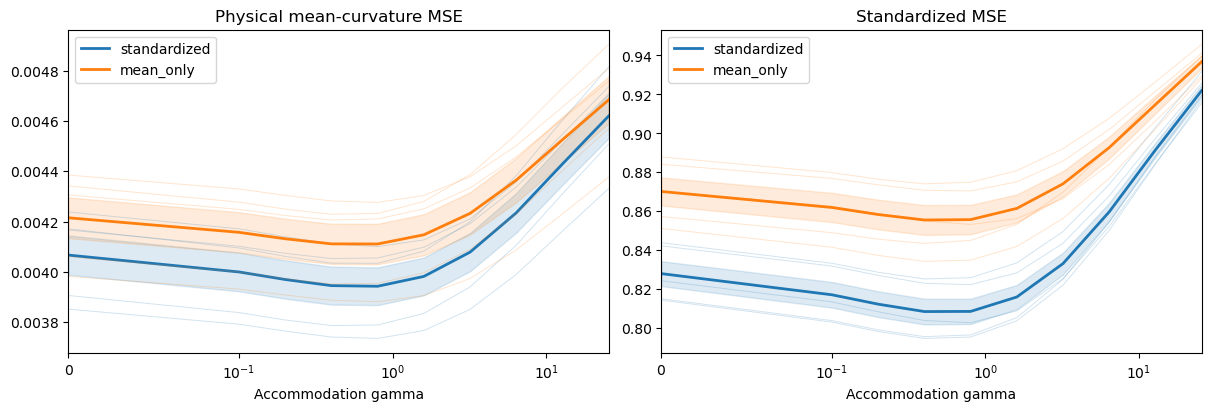

Saved models, observed moments, exact folds and comparison scores: training_results/shape_conditioned_energy_training/observed_mean_std_presence_20261002_144511
Continue in experiments/benchmarks/shape_conditioned_energy_evaluation.ipynb; this is conditional reconstruction, not fate-only prediction.


In [6]:
# Accommodation is selected using inner-training validation, never the outer or spherical cohort.
selection=[]
for fold in [s['fold'] for s in membership]:
    for mode in SETTINGS['target_modes']:
        candidates=[r for r in records if r['fold']==fold and r['target_mode']==mode and r['variant']=='presence_energy']
        best=min(candidates,key=lambda r:r['inner_mse']);selection.append(dict(fold=fold,target_mode=mode,key=best['key'],gamma=best['gamma'],inner_mse=best['inner_mse']))
pd.DataFrame(selection).to_csv(RUN_DIR/'selected_models.csv',index=False)
scores=pd.concat([pd.DataFrame(score_rows),pd.DataFrame(gin_rows)],ignore_index=True)
scores.to_csv(RUN_DIR/'validation_mse.csv',index=False)
fig,axes=plt.subplots(1,2,figsize=(12,4),layout='constrained')
for ax,metric,title in zip(axes,['mse','standardized_mse'],['Physical mean-curvature MSE','Standardized MSE']):
    for mode,color in [('standardized','tab:blue'),('mean_only','tab:orange')]:
        d=scores[(scores.variant=='presence_energy')&(scores.target_mode==mode)&(scores.cohort=='val')]
        fold=d.groupby(['fold','gamma'])[metric].mean().reset_index()
        for _,f in fold.groupby('fold'):ax.plot(f.gamma,f[metric],color=color,alpha=.2,lw=.7)
        curve=fold.groupby('gamma')[metric].agg(['mean','sem']);x=curve.index.to_numpy()
        ax.plot(x,curve['mean'],color=color,lw=2,label=mode);ax.fill_between(x,curve['mean']-curve['sem'],curve['mean']+curve['sem'],color=color,alpha=.15)
    ax.set_xscale('symlog',linthresh=.1);ax.set_xlim(min(SETTINGS['gamma_grid']),max(SETTINGS['gamma_grid']));ax.set(title=title,xlabel='Accommodation gamma');ax.legend()
fig.savefig(RUN_DIR/'training_validation.png',dpi=160);plt.show()
(RUN_DIR/'complete.json').write_text(json.dumps(dict(models=len(records),folds=len(membership),conditional_moments=True,selection='inner validation only'),indent=2))
for filename in ['src/data/target_transforms.py','src/models/curvature_energy.py','src/models/energy_ops.py','src/training/energy_fit.py','experiments/training/shape_conditioned_energy_training.ipynb']:
    dest=RUN_DIR/'source_snapshot'/filename;dest.parent.mkdir(parents=True,exist_ok=True);shutil.copy2(PROJECT_ROOT/filename,dest)
print('Saved models, observed moments, exact folds and comparison scores:',RUN_DIR)
print('Continue in experiments/benchmarks/shape_conditioned_energy_evaluation.ipynb; this is conditional reconstruction, not fate-only prediction.')
